## IBUG — Instance-Based Uncertainty Estimation for Gradient-Boosted Regression Trees (Brophy & Lowd, NeurIPS 2022)

**Individual component — Simen Bugge**

---

### What is IBUG?

IBUG wraps around a existing gradient-boosted regression tree and adds probability predictions without need for retraining. But since the best model we made was a multimodal neural network, i need to train a new model on the same tabular features and then apply IBUG on top. For this i have chosen an XGBoost regression model trained on tabular features from the full dataset. 

#### The notebook follows this pipeline:
 - Load the necessary data 
 - Train a baseline XGBoost model
 - Apply IBUG
 - Evaluate uncerainty quality 
 - Plot results 

#### Imports and setup
Similarities from *NNpipeline* for comparable results

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

import xgboost as xgb
from scipy.stats import norm
from scipy.optimize import minimize_scalar

import warnings
warnings.filterwarnings('ignore')

In [43]:
SEED = 376 #changed to combat underfitting in specific runs 
random.seed(SEED)
np.random.seed(SEED)

In [44]:
DataPath  = Path("..") / "Processed data"
ModelPath = Path("..") / "Models"

### Columns - from NNpipeline

In [45]:
numeric_cols = [
    'deflated_gdp_usd',
    'us_cpi',
    'straight_distance_to_capital_km',
    'quarter_label'
]

categorical_cols = [
    "geolocation_name",
    "country",
    "landlocked",
    "region_economic_classification",
    "access_to_airport",
    "access_to_port",
    "access_to_highway",
    "access_to_railway",
    "seismic_hazard_zone",
    "flood_risk_class",
    "tropical_cyclone_wind_risk",
    "tornadoes_wind_risk",
    "koppen_climate_zone",
]

target_col = 'construction_cost_per_m2_usd'
img_col    = "processed_imgs"
id_col     = "data_id"

### Root Mean Squared Logarithmic Error

In [46]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
   matches RMSLELoss() in NNpipeline.ipynb.
    """
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

## Load data 

The full processed dataset from *processed_data.csv* is loaded and split into train/validation/test using the same 60/20/20 strategy as in *NNpipeline.ipynb*. 

Only keep tabular data, images are not used since XGBoost is a tabular model.

In [47]:
# first full dataset load and split, to mirror NNpipeline.ipyn

full_df = pd.read_csv(DataPath / "processed_data.csv")
print(f"Full dataset shape: {full_df.shape}")

# Tabular feature columns: numeric + categorical
feature_cols = [c for c in numeric_cols + categorical_cols if c in full_df.columns]
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

X = full_df[feature_cols].values.astype(np.float32)
y = full_df[target_col].values.astype(np.float32)

# Same 60/20/20 split strategy as NNpipeline.ipynb
X_trainval, X_test,  y_trainval, y_test  = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train,    X_val,   y_train,    y_val   = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=SEED)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Full dataset shape: (1024, 21)
Feature columns (17): ['deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km', 'quarter_label', 'geolocation_name', 'country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']
Train: (614, 17), Val: (205, 17), Test: (205, 17)


# Train Base XGBoost Model

XGBoost is used since it is a tree-based model well made for tabular data. It also has 'apply()' method that returns leaf index, which is needed for IBUG.

Overlook of the hyperparameter choices:
- *max_depth=4* keeps the trees small to avoid overfitting
- *min_child_weight=5* ensures each leaf has enough samples
- *reg_alpha=0.1* adds some regularisation
- *subsample=0.8* and *colsample_bytree=0.8* add randomness, which usually helps generalisation 
- *early_stopping_rounds=30* prevents overfitting by stopping training if there is no improvement


In [64]:
# running with a few different seeds to see variance
# the last one (2026) ends up being used for IBUG

base_val_results = []
base_test_results = []

for testseed in [1, 42, 123, 367, 2026]:
    xgb_model = xgb.XGBRegressor(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 4,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_weight  = 5,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        random_state      = testseed,
        n_jobs            = -1,
        early_stopping_rounds = 30,
        eval_metric       = 'rmse',
    )

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    print(f"Val  RMSLE: {rmsle(y_val,  xgb_model.predict(X_val)):.4f}")
    print(f"Test RMSLE: {rmsle(y_test, xgb_model.predict(X_test)):.4f}")
    print(f"Best iteration: {xgb_model.best_iteration}")

    base_val_results.append(rmsle(y_val,  xgb_model.predict(X_val)))
    base_test_results.append(rmsle(y_test, xgb_model.predict(X_test)))  

#This is just to visualize differences between seeds, only one is used for fitting
print(f"\nAverage Val  RMSLE: {np.mean(base_val_results):.4f}")
print(f"Average Test RMSLE: {np.mean(base_test_results):.4f}")

Val  RMSLE: 0.2100
Test RMSLE: 0.2065
Best iteration: 264
Val  RMSLE: 0.2097
Test RMSLE: 0.2090
Best iteration: 229
Val  RMSLE: 0.2095
Test RMSLE: 0.2120
Best iteration: 176
Val  RMSLE: 0.2113
Test RMSLE: 0.2096
Best iteration: 219
Val  RMSLE: 0.2105
Test RMSLE: 0.2110
Best iteration: 194

Average Val  RMSLE: 0.2102
Average Test RMSLE: 0.2096


## Implementation of IBUG
Reference: Brophy & Lowd, *Instance-Based Uncertainty Estimation for Gradient-Boosted Regression Trees*, NeurIPS 2022.

Each tree sends the input to a leaf (bottom node). If two samples end up in the same leaf a lot, they're 'close' to each other. As shown in the paper, the affinity between the test point $x_{te}$ and a training point $x_i$ is:
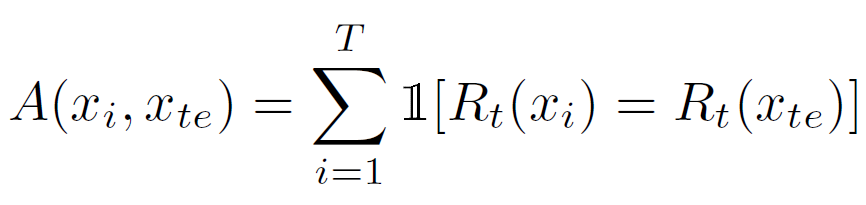

Where T is the number of trees, and $R_t(x)$ is the leaf index of $x$ in tree T.


Plainly said you count how often two points end up in the same leaf and average it over all the trees

In [ ]:
class IBUG:
    """
    Instance-Based Uncertainty Estimation for Gradient-Boosted Regression Trees.
    From Brophy & Lowd, NeurIPS 2022.

    Wraps around a GBRT and adds uncertainty estimates based on leaf assignments.
    Needs the model to have an apply() method - XGBoost has this.
    """

    def __init__(self, model, k=100, min_variance=1e-15):
        self.model = model
        self.k = k  # number of neighbors to use
        self.min_variance = min_variance  # avoid division by zero later
        self.gamma = 1.0   # calibration scaling factor
        self.delta = 0.0   # offset term, kept at 0
        self.train_leaves_ = None
        self.y_train_ = None


    def fit(self, X_train, y_train, X_val, y_val, k_candidates=None, verbose=True):
        """
        Stores the leaf assignments for training data, then tunes k and gamma
        on the validation set.
        """
        self.y_train_ = np.asarray(y_train, dtype=np.float64)
        self.train_leaves_ = self._get_leaves(X_train)  # shape: (n_train, n_trees)

        if k_candidates is None:
            n = len(y_train)
            # only use values smaller than the training set
            k_candidates = [k for k in [25, 50, 100, 200, 500, 1000] if k < n]

        val_leaves = self._get_leaves(X_val)
        val_preds = self.model.predict(X_val).astype(np.float64)

        # try each k and pick the one with lowest NLL on validation set
        if verbose:
            print("Tuning k:")
        best_k = None
        best_nll = np.inf
        for k in k_candidates:
            nll = self._val_nll(val_leaves, val_preds, y_val, k, gamma=1.0)
            if verbose:
                print(f"  k={k:5d}  NLL={nll:.4f}")
            if nll < best_nll:
                best_nll = nll
                best_k = k
        self.k = best_k
        if verbose:
            print(f"  -> best k={self.k}  (NLL={best_nll:.4f})")

        # now tune gamma with the best k fixed
        def nll_obj(g):
            return self._val_nll(val_leaves, val_preds, y_val, self.k, gamma=g)
        result = minimize_scalar(nll_obj, bounds=(1e-3, 1e3), method='bounded')
        self.gamma = result.x

        # use smallest nonzero variance from val set as the floor
        all_vars = [self._neighbor_var(val_leaves[i], self.k) for i in range(len(X_val))]
        nonzero_vars = [v for v in all_vars if v > 0]
        self.min_variance = min(nonzero_vars) if nonzero_vars else 1e-15

        if verbose:
            print(f"  -> gamma={self.gamma:.4f}")
            print(f"  -> min_variance={self.min_variance:.2e}")
        return self


    def predict(self, X):
        """
        Returns point predictions and variance estimates for each sample.
        The means are just the normal XGBoost predictions.
        """
        means = self.model.predict(X).astype(np.float64)
        leaves = self._get_leaves(X)

        variances = []
        for i in range(len(X)):
            v = self.gamma * self._neighbor_var(leaves[i], self.k) + self.delta
            v = max(v, self.min_variance)  # clamp so variance is never 0
            variances.append(v)
        variances = np.array(variances)

        return means, variances

    def predict_interval(self, X, alpha=0.90):
        """Returns prediction intervals at the given confidence level."""
        means, variances = self.predict(X)
        z = norm.ppf((1 + alpha) / 2)
        stds = np.sqrt(variances)
        lower = means - z * stds
        upper = means + z * stds
        return means, lower, upper

    def nll(self, X, y):
        """Mean negative log-likelihood. Lower means better calibrated."""
        means, variances = self.predict(X)
        nll_vals = -norm.logpdf(np.asarray(y), loc=means, scale=np.sqrt(variances))
        return float(np.mean(nll_vals))

    def coverage(self, X, y, alpha=0.90):
        """Fraction of true values that fall inside the predicted interval."""
        _, lowers, uppers = self.predict_interval(X, alpha)
        y = np.asarray(y)
        inside = (y >= lowers) & (y <= uppers)
        return float(np.mean(inside))


    # helpesr

    def _get_leaves(self, X):
        """Returns which leaf each sample lands in, for each tree."""
        leaves = self.model.apply(X)
        if leaves.ndim == 3:  # xgboost 2.x returns (n, n_trees, 1)
            leaves = leaves[:, :, 0]
        return leaves.astype(np.int32)

    def _neighbor_var(self, query_leaves, k):
        """
        Finds the k most similar training points to the query and returns
        the variance of their targets. Similarity = number of shared leaves.
        """
        affinities = np.sum(self.train_leaves_ == query_leaves, axis=1)
        top_k = np.argpartition(affinities, -k)[-k:]
        return float(np.var(self.y_train_[top_k]))

    def _val_nll(self, val_leaves, val_preds, y_val, k, gamma):
        """Average NLL on the validation set for a given k and gamma."""
        total_nll = 0.0
        for i in range(len(y_val)):
            sigma2 = max(gamma * self._neighbor_var(val_leaves[i], k), self.min_variance)
            total_nll += -norm.logpdf(float(y_val[i]), loc=val_preds[i], scale=np.sqrt(sigma2))
        return total_nll / len(y_val)
   

# Fit IBUG

The final seed used for the model fitted for IBUG is 2026 since it was the last in the list.
But it does not really matter since again, we are not going for the best performance possible, but rather the uncertainty element

In [66]:
ibug = IBUG(xgb_model) 
ibug.fit(X_train, y_train, X_val, y_val,
         k_candidates=[25, 50, 100, 200, 500])

Tuning k:
  k=   25  NLL=6.5329
  k=   50  NLL=6.5181
  k=  100  NLL=6.5140
  k=  200  NLL=6.4894
  k=  500  NLL=7.6460
  -> best k=200  (NLL=6.4894)
  -> gamma=1.0537
  -> min_variance=2.94e+03


# Evaluation with relevant metrics

In [67]:
means, variances = ibug.predict(X_test)
stds = np.sqrt(variances)

# point metric - same as NNpipeline
test_rmsle = rmsle(y_test, means)

# probabilistic metrics
test_nll = ibug.nll(X_test, y_test)

# CRPS - proper scoring rule, lower is better
crps_vals = []
for i in range(len(y_test)):
    mu = means[i]
    sig = stds[i]
    yi = y_test[i]
    crps_i = (
        (yi - mu) * (2 * norm.cdf(yi, mu, sig) - 1)
        + 2 * sig * norm.pdf(yi, mu, sig)
        - sig / np.sqrt(np.pi)
    )
    crps_vals.append(crps_i)
test_crps = float(np.mean(crps_vals))

cov_90 = ibug.coverage(X_test, y_test, alpha=0.90)
cov_50 = ibug.coverage(X_test, y_test, alpha=0.50)


print(f"  Test RMSLE     : {test_rmsle:.4f}   (point metric)")
print(f"  Test NLL       : {test_nll:.4f}   (lower is better)")
print(f"  Test CRPS      : {test_crps:.4f}   (lower is better)")
print(f"  Coverage @ 90% : {cov_90:.3f}    (target 0.900)")
print(f"  Coverage @ 50% : {cov_50:.3f}    (target 0.500)")
print("-------------------------------------------")
print(f"  k              : {ibug.k}")
print(f"  gamma          : {ibug.gamma:.4f}")

  Test RMSLE     : 0.2110   (point metric)
  Test NLL       : 6.3564   (lower is better)
  Test CRPS      : -55.3332   (lower is better)
  Coverage @ 90% : 0.946    (target 0.900)
  Coverage @ 50% : 0.668    (target 0.500)
-------------------------------------------
  k              : 200
  gamma          : 1.0537


## Evaluation

Three probabilistic metrics are reported alongside RMSLE:

- **NLL (Negative Log-Likelihood):** measures how well the predicted Gaussian distribution fits the data. Lower is better. Sensitive to both mean accuracy and calibration of the variance.
- **CRPS (Continuous Ranked Probability Score):** a *proper scoring rule* — it rewards sharp, accurate distributions and cannot be gamed. The closed-form expression for a Gaussian is used here (derived in Gneiting & Raftery, 2007). Lower is better. Units are the same as the target (USD/m²).
- **Coverage @ α%:** the fraction of test targets that fall inside the α-level prediction interval. A well-calibrated model should produce coverage close to the nominal level (0.90 and 0.50 are checked).

# Visualisations
**Plot 1 — Prediction intervals:**  
The test samples are sorted by predicted cost. The blue area shows the prediction interval, and the red dots are the true values. If the uncertainty is good, about 90% of the red dots should be inside the blue area.  

From the plot, the intervals seem to get wider for more expensive buildings, which makes sense since those are usually harder to predict.

**Plot 2 — Uncertainty vs error:**  
This plot compares the model’s uncertainty with the actual prediction error. Ideally, points with higher uncertainty should also have higher error.  

The correlation coefficient \( r \) is used to measure this relationship.

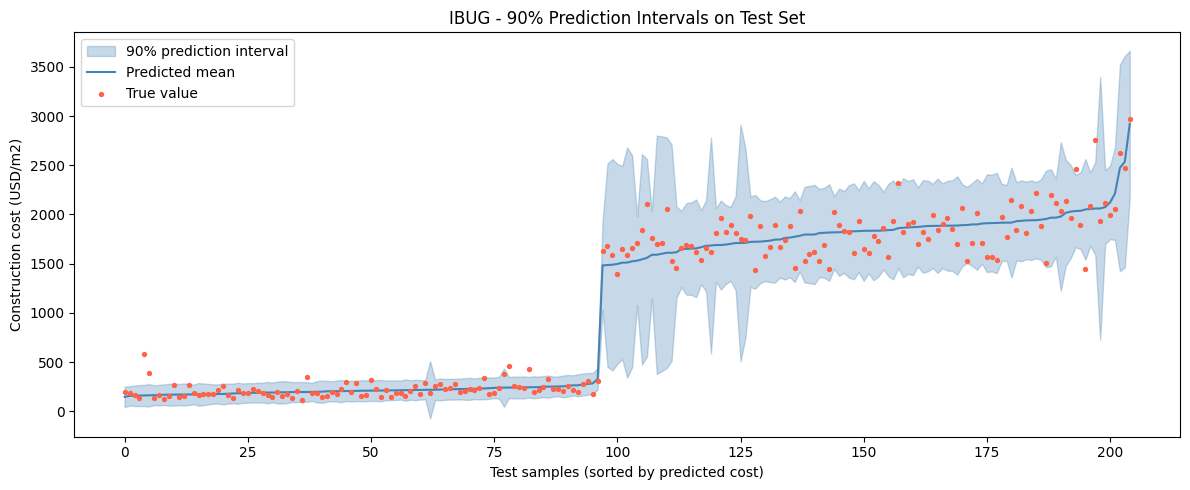

In [68]:
# plot prediction intervals sorted by predicted mean
_, lowers, uppers = ibug.predict_interval(X_test, alpha=0.90)
order = np.argsort(means)
x_idx = np.arange(len(means))

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_idx, lowers[order], uppers[order],
                alpha=0.3, color='steelblue', label='90% prediction interval')
ax.plot(x_idx, means[order], color='steelblue', lw=1.5, label='Predicted mean')
ax.scatter(x_idx, y_test[order], s=8, color='tomato', zorder=5, label='True value')

ax.set_xlabel('Test samples (sorted by predicted cost)')
ax.set_ylabel('Construction cost (USD/m2)')
ax.set_title('IBUG - 90% Prediction Intervals on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('ibug_prediction_intervals.png', dpi=150)
plt.show()

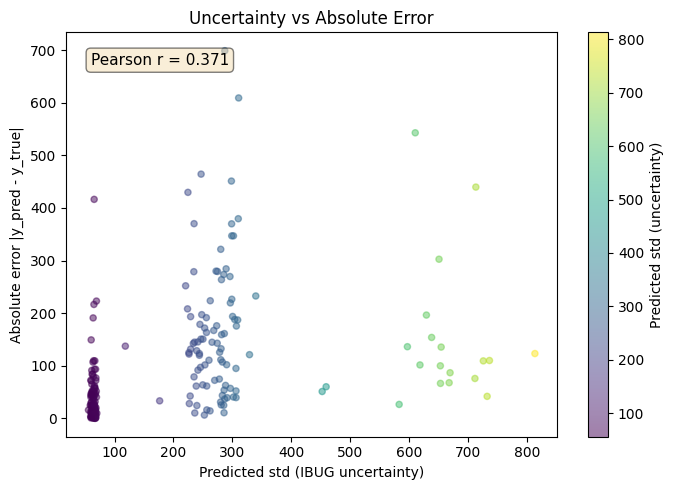

Uncertainty-error correlation: r = 0.371


In [69]:
# check if uncertainty correlates with actual error - good calibration = high correlation
errors = np.abs(means - y_test)
corr = float(np.corrcoef(stds, errors)[0, 1])

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(stds, errors, alpha=0.5, s=20, c=stds, cmap='viridis')
plt.colorbar(sc, ax=ax, label='Predicted std (uncertainty)')
ax.set_xlabel('Predicted std (IBUG uncertainty)')
ax.set_ylabel('Absolute error |y_pred - y_true|')
ax.set_title('Uncertainty vs Absolute Error')
ax.text(0.05, 0.92, f'Pearson r = {corr:.3f}', transform=ax.transAxes,
        fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('ibug_uncertainty_vs_error.png', dpi=150)
plt.show()

print(f"Uncertainty-error correlation: r = {corr:.3f}")

## SUmmary

The results look reasonable overall:

 - Coverage @ 90% = 0.946 — a bit above the target of 0.90, so the intervals are slightly too wide. Better than being too narrow though.
 - Coverage @ 50% = 0.668 — further off from the target of 0.50, meaning the model is over-cautious at the 50% level. Tuning gamma helps but doesn't fully fix this.
 -  Uncertainty-error correlation r = 0.371 — positive correlation, so the uncertainty estimates do carry some useful information. Not perfect but not random either.

### Limitations
The XGBoost base model gets an RMSLE of around 0.211, which is worse than the group's neural network (~0.17). The uncertainty estimates are only as good as the underlying model, so this is a ceiling on how useful IBUG can be here. The dataset is also pretty small (1,024 rows), which makes it harder for the leaf co-occurrence similarity to work well.